# Ensembles in phase-space

:::{admonition} **What you will learn**

- Counting microstates in quantum systems or lattice models is natural as these systems are already discretized
- Defining microstates in classical mechanics requires us to divide phase-space into small volumes of size $\sim h^N$
- Using classical Hamiltonians for non-interacting particles we can derive a number of useful relations between free energies chemical potentials.
- Equipartition theorem says ever quadratic degree term in Hamiltonian contributes $kT$ of energy
- De Broglie wavelength demarcates domain of applicability of classical and quantum mechanics

:::

### Quantization of Phase Space in Units of $ h $

:::{figure} 

<img src="./figs/1d-pspace.png" class="bg-primary" width="300px">  

Illustration of phase space for a 1D particle in a box.

:::  

- In classical mechanics, a system's state is represented as a point in **phase space**, with coordinates $(x, p)$ for each degree of freedom. The number of microstates is, in principle, infinite because both position and momentum can vary continuously.
- However, in quantum mechanics, the Heisenberg uncertainty principle imposes a fundamental limit on how precisely position and momentum can be specified:


- This implies that **we cannot resolve phase space with arbitrary precision**. Instead, each distinguishable quantum state occupies a **minimum phase space volume** on the order of:

$$
\Delta x \, \Delta p \sim h
$$

- For a system with $ f $ degrees of freedom (e.g $3N$ for $N$ particles in three dimensions), the smallest resolvable cell in phase space has volume:

$$
(\Delta x \, \Delta p)^f \sim h^f
$$


- To compute the number of accessible microstates $ \Omega $ in a given region of phase space, we divide the **classical phase space volume** $ \Gamma $ by the smallest quantum volume $h^f$
- Since N particles are indistingusihable and classical mechanics has no such concept we have to manually divide numer of microstates by $N!$

$$
\Omega(E) = \frac{\Gamma}{h^f N!}
$$


- An explicit expression for number of microstates for a given energy $E$ is written by using delta function which counts all microstates in phase-space where $H(p^N, x^N)=E$ 

:::{admonition} **Microcanonical partition function in phase-space**
:class: important

$$
\Omega(E) =  \frac{1}{N! h^N}\int dp^N dx^N \delta \big(H(p^N, x^N)-E\big)
$$

:::



:::{admonition} **Phase-space of a harmonic oscillator**
:class: tip, dropdown

$$
H(x, p) = \frac{p^2}{2m} + \frac{1}{2} m \omega^2 x^2
$$

- $ x $ = position, $ p $ = momentum, $ m $ = mass, $ \omega $ = angular frequency  

- This Hamiltonian gives the **total energy** $ E $ of a particle undergoing simple harmonic motion.


- Setting $ H(x, p) = E $, we get the **constant-energy curve**:

$$
\frac{x^2}{\left( \sqrt{\frac{2E}{m \omega^2}} \right)^2} + \frac{p^2}{\left( \sqrt{2mE} \right)^2} = 1
$$

- This is the equation of an **ellipse** in the $ (x, p) $ phase space, with:

    - Semi-major axis: $ a = \sqrt{\frac{2E}{m \omega^2}} $ (in $ x $)  
    - Semi-minor axis: $ b = \sqrt{2mE} $ (in $ p $)  


**Compute Area of the Ellipse (Classical Action)**

$$
A = \pi a b = \pi \sqrt{\frac{2E}{m \omega^2}} \cdot \sqrt{2mE} = \frac{2\pi E}{\omega}
$$

- Plugging in quantum mechanical expression of quantized energies of harmonic oscillator

$$E= \hbar\omega\bigg(n+\frac{1}{2} \bigg)$$

- This area corresponds to the **classical action integral** $ \oint p \, dx $, which in semiclassical quantization becomes:

$$
\oint p \, dx = (n + \tfrac{1}{2}) h
$$

:::


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

hbar = 1.0
m    = 1.0
omega = 1.0

n_values = [0, 1, 2, 5, 10]
colors = plt.cm.viridis(np.linspace(0, 1, len(n_values)))

fig, ax = plt.subplots(figsize=(5, 5))
theta = np.linspace(0, 2*np.pi, 500)

for n, c in zip(n_values, colors):
    E_n = hbar * omega * (n + 0.5)
    a = np.sqrt(2 * E_n / (m * omega**2))  # x semi-axis
    b = np.sqrt(2 * m * E_n)               # p semi-axis
    ax.plot(a * np.cos(theta), b * np.sin(theta), color=c, label=f"$n={n}$")

ax.set_xlabel("Position $x$")
ax.set_ylabel("Momentum $p$")
ax.set_title("Harmonic oscillator: constant-energy ellipses\n"
             r"Area $= \pi ab = 2\pi E/\omega = (n+\frac{1}{2})\,h$")
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Computing Z via classical mechanics

- In quantum mechanics counting microstates is easy, we have discrete energies and could simply sum over microstates to compute partition functions 

$$Z=\sum_i e^{-\beta E_i}$$

- Counting microstates in classical mechanics is therefore done by discretizing phase space for N particle system $x^N, p^N$ into smallest unit boxes of size $h^N$.

$$\sum_i \rightarrow \int \frac{dpdx}{h}$$

- Once agan to correct classical mechanics for "double counting" of microstates if we have N indistinguishable "particles" with a factor of $N!$  

:::{admonition} **Classical partition function**
:class: important 

$$Z(\beta) = \frac{1}{N! h^{N}} \int e^{-\beta H(x^N, p^N)} dx^N dp^N$$

:::

## The power and utility of NVT: The non-interacting system

- For the independent particle system, the energy of each particle enter the total energy of the system additively.  

$$E(\epsilon_1, \epsilon_2, ... \epsilon_N) = \epsilon_1+\epsilon_2+...\epsilon_N$$

- The exponential factor in the partition function allows decoupling particle contributions $e^{-\beta{(\epsilon_1+\epsilon_2)}} = e^{-\beta{\epsilon_1}}e^{-\beta{\epsilon_2}}$. This means that the partition function can be written as the product of the partition functions of individual particles!

**Distinguishable states**:

$$Z = z_1 \cdot z_2 \cdot z_3 ... z_N$$

**Indistinguishable states**:

$$ Z = \frac{1}{N!}z^N $$

:::{admonition} **General strategy for using NVT for simple non-interacting systems**
:class: tip

1. Compute the **single particle partition function** $z= e^{-\beta \epsilon_1}+  e^{-\beta \epsilon_2}+ ...$

2. To compute **full partition function**, raise z to the power of N and apply factorial in case of indistinguishable particles  $Z = \frac{1}{N!}z$ or take product in case of distinguishable identical particles $z^N$

3. Compute the **free energy** $F= - k_B T log Z$

4. Take **derivatives of free energy** to get the thermodynamic quantities. E.g one is often interested in computing temperature dependence of $\mu(T), U(T), S(T)$
:::

### Maxwell-Boltzmann distribution

The momentum distribution factorizes from the position distribution and is always Gaussian — independent of the interaction potential. This leads to the universal Maxwell-Boltzmann speed distribution for any equilibrium system.

- Since the kinetic and potential energy functions depend separately on momenta and positions, the total probability distribution **factorizes** into a product of position and momentum distributions:

$$
H(p^N, r^N) = U(r^N) + K(p^N) = U(r^N) + \sum_{i=1}^{N} \frac{p_i^2}{2m}
$$

- This separation leads to:

$$
P(r^N, p^N) = P(r^N) \cdot P(p^N) = \int_V dr^N \, e^{-\beta U(r^N)} \cdot \int_{-\infty}^{+\infty} dp^N \, e^{-\beta \sum_{i=1}^{N} \frac{p_i^2}{2m}}
$$

- The integral with the position-dependent potential for interacting particle system is impossible to evaluate except by simulations or numerical techniques

- The momentum-dependent part splits into individual integrals for every particle and is always a **simple quadratic function**, making it analytically tractable:

$$
P(p^N) = \left[ \int_{-\infty}^{+\infty} dp \, e^{-\beta \frac{p^2}{2m}} \right]^N
$$


- The momentum (or velocity) distribution follows the **Maxwell-Boltzmann distribution** in all equilibrium systems, regardless of the complexity of the molecular interactions.


:::{admonition} **Maxwell-Boltzmann Velocity Distribution: Full Derivation**
:class: tip, dropdown

 **Separation of variables**

- In equilibrium, the distribution of velocities in the $x$, $y$, and $z$ directions are **independent and identical**, because there's no preferred direction in an ideal gas. Therefore, we can write the joint probability distribution as:

$$
f(v_x, v_y, v_z) = f(v_x)f(v_y)f(v_z)
$$

- Furthermore, the probability of finding a particle with velocity components between $(v_x, v_x + dv_x)$, $(v_y, v_y + dv_y)$, and $(v_z, v_z + dv_z)$ is:

$$
f(v_x, v_y, v_z) dv_x dv_y dv_z
$$

 **Form of the velocity component distribution**

- The system is in thermal equilibrium, so the probability of a particle having a certain velocity corresponds to the **Boltzmann factor** for its kinetic energy:

$$
\text{Probability} \propto e^{-E_{\text{kin}} / k_B T}
$$

- For a single particle of mass $m$, the kinetic energy is:

$$
E_{\text{kin}} = \frac{1}{2}m(v_x^2 + v_y^2 + v_z^2)
$$

- So we postulate:

$$
f(v_x, v_y, v_z) \propto e^{-m(v_x^2 + v_y^2 + v_z^2)/2k_B T}
$$

- Using the independence of the components:

$$
f(v_x) \propto e^{- m v_x^2 / 2 k_B T}
$$

- We require that:

$$
\int_{-\infty}^\infty f(v_x) dv_x = 1
$$

- This is a standard Gaussian integral of form $p(x) = \frac{1}{\sqrt{2\pi \sigma^2}} e^{-\frac{x^2}{2\sigma^2}}$ where $\sigma^2 = \frac{k_B T}{m}$ and therefore we write down:

$$
f(v_x) = \sqrt{\frac{m}{2\pi k_B T}} \, e^{- \frac{1}{2} m v_x^2 / k_B T}
$$

**Distribution of speeds**

- Now, let’s consider the **speed** $v = \sqrt{v_x^2 + v_y^2 + v_z^2}$.

- The probability density for the speed (regardless of direction) is obtained by converting to spherical coordinates in velocity space. The volume element in velocity space becomes:

$$
dv_x dv_y dv_z = v^2 \sin\theta \, dv \, d\theta \, d\phi
$$

- Integrating over angles gives a factor of $4\pi$:

$$
f(v) dv = \underbrace{4\pi v^2}_{\text{Jacobian}} \cdot f(v_x)f(v_y)f(v_z) dv
$$

- Substitute in the expressions for $f(v_x)$, $f(v_y)$, and $f(v_z)$, and recall that the total exponent is:

$$
f(v_x)f(v_y)f(v_z) = \left(\frac{m}{2\pi k_B T}\right)^{3/2} e^{-\frac{1}{2} m (v_x^2 + v_y^2 + v_z^2) / k_B T} = \left(\frac{m}{2\pi k_B T}\right)^{3/2} e^{- \frac{1}{2} m v^2 / k_B T}
$$

- Therefore, the **speed distribution** is:

$$
f(v) = 4\pi v^2 \left( \frac{m}{2\pi k_B T} \right)^{3/2} e^{- \frac{1}{2} m v^2 / k_B T}
$$

- This is the **Maxwell-Boltzmann speed distribution**. It gives the probability density that a particle in a gas has speed $v$.

:::

:::{admonition} **Maxwell-Boltzmann distribution**
:class: important

- **Velocity component distribution** (1D Gaussian):

$$
f(v_x) = \sqrt{\frac{m}{2\pi k_B T}} \, e^{- \frac{1}{2} m v_x^2 / k_B T}
$$

- **Speed distribution** (Maxwell-Boltzmann form):

$$
f(v) = 4\pi v^2 \left( \frac{m}{2\pi k_B T} \right)^{3/2} e^{- \frac{1}{2} m v^2 / k_B T}
$$

- $ v $ is the speed of a particle,
- $ m $ is the mass of a particle,
- $ k_B $ is Boltzmann’s constant,
- $ T $ is the absolute temperature.
:::


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

k_B = 1.38e-23   # J/K
m   = 4.65e-26   # kg  (nitrogen molecule, approximate)
T   = 300        # K

v = np.linspace(0, 2000, 1000)

def f_MB(v, m, T):
    return 4*np.pi * v**2 * (m / (2*np.pi*k_B*T))**(3/2) * np.exp(-m*v**2 / (2*k_B*T))

v_mp  = np.sqrt(2   * k_B*T / m)
v_avg = np.sqrt(8   * k_B*T / (np.pi*m))
v_rms = np.sqrt(3   * k_B*T / m)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(v, f_MB(v, m, T), color='black', label="Maxwell-Boltzmann")
ax.axvline(v_mp,  color='C0', ls='--', label=f"$v_{{mp}}$  = {v_mp:.0f} m/s")
ax.axvline(v_avg, color='C2', ls='--', label=f"$\\langle v \\rangle$ = {v_avg:.0f} m/s")
ax.axvline(v_rms, color='C3', ls='--', label=f"$v_{{rms}}$ = {v_rms:.0f} m/s")
ax.set_xlabel("Speed (m/s)")
ax.set_ylabel("Probability density")
ax.set_title("Maxwell-Boltzmann speed distribution — $N_2$ at 300 K")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Ideal Gas

- A useful approximation is to consider the limit of a very dilute gas, known as an **ideal gas**, where interactions between particles are neglected ($U = 0$). 

- Evaluating the partition function for a single atom of an ideal gas:

$$
z(\beta) = \left[ \frac{1}{h} \int_{0}^{L} dx \int_{-\infty}^{+\infty} dp \, e^{- \frac{p^2}{2m k_B T}} \right]^3 = V \left( \frac{2\pi m k_B T}{h^2 } \right)^{3/2}  
$$

$$
z = \frac{V}{\lambda^3_T} = V n_Q
$$

:::{important} **De Broglie thermal wavelength and quantum concentration**

$$
\lambda_T = \frac{h}{\sqrt{2\pi m k_B T}}, \qquad n_Q = \frac{1}{\lambda^3_T}
$$

:::

**On the validity of the classical approximation**

- The classical approximation is valid when the average interatomic spacing $d$ is much larger than the thermal de Broglie wavelength:

$$d \gg \lambda_T \qquad \text{or equivalently} \qquad n\lambda_T^3 \ll 1$$

- This ensures that wavefunction overlap between particles is negligible, so quantum exchange statistics can be ignored and particles obey Maxwell-Boltzmann statistics for their translational motion.


:::{important} **Classical partition function for N-atom ideal gas**

$$Z = \frac{z^N}{N!}  = \frac{(V n_Q)^N}{N!}$$

$$F = -k_B T \log Z = -N k_B T  \log \left( \frac{n_Q}{n} \right) - Nk_BT$$

$$\mu = \frac{\partial F}{\partial N} = k_B T \log \left(\frac{n}{n_Q(T)}\right)$$

:::

We can also calculate entropy and other thermodynamic quantities:

$$S = -\left( \frac{\partial F}{\partial T}\right)_{N,V}  = Nk_B \left[\log \left( \frac{n_Q}{n} \right)+ \frac{5}{2} \right]$$

$$U = \frac{\partial \log Z}{\partial (-\beta)} = \frac{3}{2}N k_B T, \qquad p = -\frac{\partial F}{\partial V} =\frac{N k_B T}{V}$$

### Equipartition Theorem

- Consider a classical system with a Hamiltonian containing a **quadratic degree of freedom** $x$, such that:

$$
E(x) = \frac{1}{2} a x^2
$$

- The **canonical partition function** for this degree of freedom is:

$$
Z = \int_{-\infty}^{\infty} e^{-\beta \frac{1}{2} a x^2} dx = \sqrt{\frac{2\pi}{\beta a}}
$$

- The **average energy** is:

$$
\langle E \rangle = -\frac{\partial \log Z}{\partial \beta}
$$

$$
\log Z = \frac{1}{2} \log \left( \frac{2\pi}{\beta a} \right) = \text{const} - \frac{1}{2} \log \beta
$$

$$
\langle E \rangle = -\frac{\partial}{\partial \beta} \left( -\frac{1}{2} \log \beta \right) = \frac{1}{2\beta} = \frac{1}{2} k_B T
$$

:::{admonition} **equipartition function for $f$ independent quadratic degrees of freedom**

$$
\langle E \rangle = \frac{f}{2} k_B T
$$

:::


#### Examples

- **Monatomic ideal gas**: 3 translational degrees → $\langle E \rangle = \frac{3}{2} k_B T$
- **Diatomic molecule** at high $T$: 3 translational + 2 rotational + $n$ active vibrational modes  
  → $\langle E \rangle = \left( \frac{5}{2} + n \right) k_B T$

> **Note**: Equipartition only applies when the quadratic modes are **thermally accessible**, i.e., when $k_B T \gg$ energy level spacing (e.g., $\hbar \omega$ for vibrations).



### Partition functions for non-interacting molecules

- Total energy and partition function for a molecule with separable degrees of freedom:

:::{admonition} **Partition Function for a Molecular Gas**
:class: important 

$$
E = E_{\text{transl}} + E_{\text{vib}} + E_{\text{rot}} + E_{\text{elec}}
$$

$$
Z = Z_{\text{transl}} \cdot Z_{\text{vib}} \cdot Z_{\text{rot}} \cdot Z_{\text{elec}}
$$

:::

### Translational degrees of freedom: particle in a box

- For a particle in a 3D box of volume $V = L^3$, the energy levels are:

$$
E_{n_x, n_y, n_z} = \frac{\hbar^2 \pi^2}{2m L^2} \left(n_x^2 + n_y^2 + n_z^2 \right)
$$

- At high temperatures (many levels populated), we replace the discrete sum with an integral:

$$
Z \approx \left[ \int_0^\infty dn\, e^{-\beta \frac{\hbar^2 \pi^2}{2m L^2} n^2} \right]^3 = \left( \frac{L}{h} \sqrt{2 \pi m k_B T} \right)^3 = V n_Q
$$

- For $N$ indistinguishable molecules:

$$
Z = \frac{(V n_Q)^N}{N!}
$$

### Vibrational degrees of freedom: harmonic oscillator

- Energy levels: $E_n = \hbar\omega(n + \tfrac{1}{2})$. Partition function for one mode:

$$
z = \frac{e^{-\frac{1}{2}\beta\hbar\omega}}{1 - e^{-\beta\hbar\omega}}
$$

- Average energy for $N$ independent oscillators:

$$
\langle E \rangle = N\hbar\omega\left(\frac{1}{2} + \frac{1}{e^{\beta\hbar\omega}-1}\right)
$$

- **Low T** ($T \to 0$): $\langle E \rangle \to \tfrac{1}{2}N\hbar\omega$ — zero-point energy only.  
- **High T** ($T \to \infty$): $\langle E \rangle \to Nk_BT$ — classical equipartition recovered.

### Rotational degrees of freedom: rigid rotor

- For a linear molecule (diatomic rotor), the rotational energy levels are:

$$
E_J = \frac{\hbar^2}{2I} J(J + 1), \quad \text{degeneracy } (2J + 1)
$$

- At high temperatures ($k_B T \gg \hbar^2 / 2I$), the sum becomes an integral:

$$
Z \approx \int_0^\infty (2J + 1)\, e^{-\beta \frac{\hbar^2}{2I} J(J + 1)}\, dJ = \frac{2I k_B T}{\hbar^2} = \frac{T}{\theta_{\text{rot}}}
$$

where $\theta_{\text{rot}} = \hbar^2 / 2Ik_B$ is the **rotational temperature**.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

k_B       = 1.0          # work in units of k_B
hbar_omega = 1.0         # energy quantum (sets the scale)

T_vals = np.linspace(0.05, 5.0, 500)   # in units of ℏω/k_B
x      = hbar_omega / T_vals           # dimensionless ℏω/k_BT

C_v = k_B * x**2 * np.exp(x) / (np.exp(x) - 1)**2

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(T_vals, C_v, color='darkorange', lw=2)
ax.axhline(1, color='gray', ls='--', lw=1, label=r"Classical limit $k_B$")
ax.set_xlabel(r"$k_B T \,/\, \hbar\omega$")
ax.set_ylabel(r"$C_V \,/\, k_B$")
ax.set_title("Heat capacity of a quantum harmonic oscillator")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### On heat capacity of harmonic-oscillators

#### Einstein Model of solids
- A simple model for solids due to Einstein describes it as $N$ independent harmonic oscillators representing localized atomic vibrations.
- The average energy of a quantum harmonic oscillator is:

$$
\langle E \rangle = \hbar \omega \left( \frac{1}{2} + \frac{1}{e^{\beta \hbar \omega} - 1} \right)
$$

- The heat capacity is the derivative:

$$
C_V = \frac{\partial \langle E \rangle}{\partial T} = k_B \left( \frac{x^2 e^x}{(e^x - 1)^2} \right), \quad x = \frac{\hbar \omega}{k_B T}
$$

#### Key predictions of Einstein model of solids

- At **low T**: $C_V \to 0$ — the oscillator is frozen in its ground state.
- At **high T**: $C_V \to k_B$ — classical equipartition is recovered.


#### Debye Model of Solids

- The **Debye model** improves upon Einstein’s and matches experimental data much better than the Einstein model, especially at low temperatures.
- Main distinguishing features of Debye model are:

    - Treating atomic vibrations as a continuum of phonon modes.
    - Including a full spectrum of frequencies up to a **Debye cutoff** $\omega_D$.
    - Predicting the correct **low-temperature behavior** of solids.


$$
U = 9 N k_B T \left( \frac{T}{T_D} \right)^3 \int_0^{T_D/T} \frac{x^3}{e^x - 1} dx
$$

$$
C_V = 9 N k_B \left( \frac{T}{T_D} \right)^3 \int_0^{T_D/T} \frac{x^4 e^x}{(e^x - 1)^2} dx
$$

#### Behavior of Debye Model

- **Low T**: $C_V \propto T^3$ — from long-wavelength (acoustic) phonons.
- **High T**: $C_V \to 3R$ — classical limit.


:::{tip} **Derivation of Debye Model and phonons**
:class: collapse

- Instead of treating each atom as an independent oscillator (like in Einstein's model), Debye considered **collective vibrations** of the entire lattice — i.e., **phonons**, which are quantized sound waves.

- In 3D, the **number of vibrational modes** with frequencies less than $ \omega $ is proportional to $ \omega^3 $:

$$
g(\omega) \, d\omega = \frac{9N}{\omega_D^3} \, \omega^2 \, d\omega
$$

- $ g(\omega) $: phonon density of states
- $ N $: number of atoms
- $ \omega_D $: Debye cutoff frequency, chosen so total modes = $ 3N $


- Each mode contributes energy:

$$
\langle E(\omega) \rangle = \frac{\hbar \omega}{e^{\beta \hbar \omega} - 1}
$$

- Total internal energy:

$$
U = \int_0^{\omega_D} g(\omega) \langle E(\omega) \rangle d\omega = \int_0^{\omega_D} \frac{9N}{\omega_D^3} \omega^2 \cdot \frac{\hbar \omega}{e^{\beta \hbar \omega} - 1} d\omega
$$


$$
x = \frac{\hbar \omega}{k_B T} \quad \Rightarrow \quad \omega = \frac{k_B T}{\hbar} x, \quad d\omega = \frac{k_B T}{\hbar} dx
$$

$$
x_D = \frac{\hbar \omega_D}{k_B T} = \frac{T_D}{T}
$$

- Then the internal energy becomes:

$$
U = 9N k_B T \left( \frac{T}{T_D} \right)^3 \int_0^{x_D} \frac{x^3}{e^x - 1} dx
$$

- Now take the derivative:

$$
C_V = \frac{dU}{dT} = 9N k_B \left( \frac{T}{T_D} \right)^3 \int_0^{x_D} \frac{x^4 e^x}{(e^x - 1)^2} dx
$$

:::

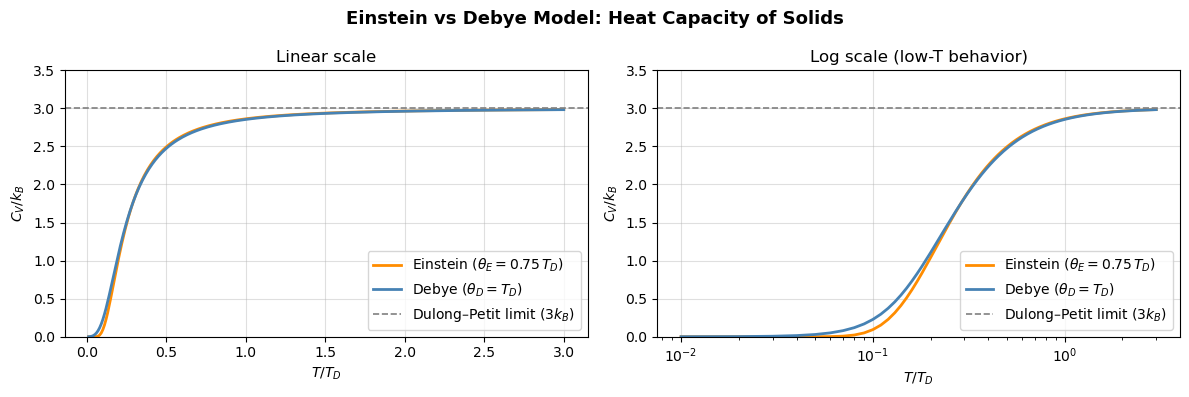

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

k_B = 1.0  # work in units of k_B

# --- Einstein model: 3 modes per atom ---
def einstein_cv(T, T_E):
    x = T_E / T
    return 3 * k_B * x**2 * np.exp(x) / (np.exp(x) - 1)**2

# --- Debye model: integrates over full phonon spectrum ---
def debye_cv(T, T_D):
    x_D = T_D / T
    integrand = lambda x: x**4 * np.exp(x) / (np.exp(x) - 1)**2
    val, _ = quad(integrand, 1e-10, x_D)
    return 9 * k_B * (T / T_D)**3 * val

T_D = 1.0
T_E = 0.75 * T_D  # empirical best-fit ratio

T_vals = np.linspace(0.01, 3.0, 300)  # in units of T_D

cv_einstein = [einstein_cv(T, T_E) for T in T_vals]
cv_debye    = [debye_cv(T, T_D)    for T in T_vals]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, xscale, title in zip(axes, ['linear', 'log'], ['Linear scale', 'Log scale (low-T behavior)']):
    ax.plot(T_vals, cv_einstein, color='darkorange', lw=2, label=r'Einstein ($\theta_E = 0.75\, T_D$)')
    ax.plot(T_vals, cv_debye,    color='steelblue',  lw=2, label=r'Debye ($\theta_D = T_D$)')
    ax.axhline(3, color='gray', ls='--', lw=1.2, label=r'Dulong–Petit limit ($3k_B$)')
    ax.set_xscale(xscale)
    ax.set_xlabel('$T / T_D$')
    ax.set_ylabel('$C_V / k_B$')
    ax.set_title(title)
    ax.set_ylim(0, 3.5)
    ax.legend()
    ax.grid(True, alpha=0.4)

fig.suptitle('Einstein vs Debye Model: Heat Capacity of Solids', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Problems

#### Problem-1 1D energy profiles

Given an energy function $E(x)=Ax^4-Bx^2+C$ with constants $(A=1,B=4,C=1)$ 

- Compute free energy difference between minima at temperature $k_BT=1,10, 100$
- Compute free energy around minima of size $\delta x = 0.1, 0.5, 1$

#### Problem-2 Maxwell-Boltzmann

You are tasked with analyzing the behavior of non-interacting nitrogen gas molecules described by the Maxwell-Boltzmann distribution:

$$
f(v) = 4\pi \left( \frac{m}{2\pi k_B T} \right)^{3/2} v^2 e^{-\frac{mv^2}{2k_B T}}
$$

Where:
- $ f(v) $ is the probability density for molecular speed $ v $
- $ m $ is the mass of a nitrogen molecule
- $ k_B = 1.38 \times 10^{-23} \,\text{J/K} $ (Boltzmann constant)
- $ T $ is the temperature in Kelvin


**Step 1: Plot the Maxwell-Boltzmann Speed Distribution**

At room temperature (T = 300, 400, 500, 600 K), plot the distribution $ f(v) $ for speeds ranging from 0 to 2000 m/s.


**Step 2: Identify Most Probable, Average, and RMS Speeds**

Compute and print:
- The **most probable speed** $ v_{mp} = \sqrt{\frac{2k_B T}{m}} $
- The **mean speed** $ \bar{v} = \sqrt{\frac{8k_B T}{\pi m}} $
- The **root mean square (RMS) speed** $ v_{rms} = \sqrt{\frac{3k_B T}{m}} $

Plot vertical lines on your plot from Step 1 to show these three characteristic speeds.

**Step 3: Speed Threshold Analysis**

Use numerical integration to calculate the **fraction of molecules** that have speeds:
- **(a)** Greater than 1000 m/s
- **(b)** Between 500 and 1000 m/s

> **Hint**: Use `scipy.integrate.quad` to numerically integrate the Maxwell-Boltzmann distribution.

#### Problem-3 Elastic Collisions

[Complete the lab](https://dpotoyan.github.io/Statmech4ChemBio/d-gas-sim-1/)

- In this problem need to modify the code to add elastic collisions to the ideal gas simulations



### Problem-4 Elementary derivation of Boltzmann's distribution

Let us do an elementary derivation of the Boltzmann distribution showing that when a macroscopic system is in equilibrium and coupled to a heat bath at temperature $T$ we have a universal dependence of probability for finding the system at different energies:

$$\boxed{P(r')/P(r)=e^{-\beta (U(r)-U(r'))}}$$

The essence of the derivation is this. Consider a vertical column of gas somewhere in the mountains.
- On one hand we have gravitational force which acts on a column between $h, h+dh$ with cross section $A$. 
- On the other hand we have pressure balance which keeps the molecules from dropping to the ground. 
- This means that we have a steady density of molecules at each height $n(h)$ for a fixed $T$. Write down this balance of forces (gravitational vs pressure) and show how density at $h$, $n(h)$ is related to density at $h=0$, $n(0)$. 

> Tip: you may use $P=nkT$ for pressure and $mgh$ for the gravitational potential energy.

### Problem-5 2D dipoles on a lattice

Consider a 2D square lattice with $M$ lattice points. On each point we have a magnetic moment that can point in four possible directions: $+x, -x, +y, -y$. Along the $y$ axis, the dipole has energy $\epsilon>0$ and along the $x$ axis $\epsilon=0$.

Dipoles are not interacting with each other and we also ignore kinetic energy of dipoles since they are fixed at lattice positions.

- Write down the partition function for this system $Z$

- Compute the average energy.

- Compute entropy per dipole $s(T)$. Evaluate the difference $S(T=\infty)-S(T=0)$. Can you see a link with the number of arrangements of dipoles?

- Compute the microcanonical partition function $\Omega(N\epsilon)$

- Show that we get the same entropy expression from both the $NVE$ and $NVT$ ensembles.